✅ Libraries imported successfully
✅ Dataset loaded: 576 rows, 6 columns

📊 DATA EXPLORATION

🔹 Shape (rows, columns): (576, 6)

🔹 Info():
<class 'pandas.core.frame.DataFrame'>
Index: 576 entries, 24 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    576 non-null    object 
 1   year       576 non-null    int64  
 2   pop        576 non-null    float64
 3   continent  576 non-null    object 
 4   lifeExp    576 non-null    float64
 5   gdpPercap  576 non-null    float64
dtypes: float64(3), int64(1), object(2)
memory usage: 31.5+ KB

🔹 Describe():
              year           pop     lifeExp     gdpPercap
count   576.000000  5.760000e+02  576.000000    576.000000
mean   1979.500000  9.996453e+06   48.506351   2126.090760
std      17.275265  1.545802e+07    8.973621   2885.552914
min    1952.000000  6.001100e+04   23.599000    298.846212
25%    1965.750000  1.616402e+06   42.106750    744.873915
50%    19

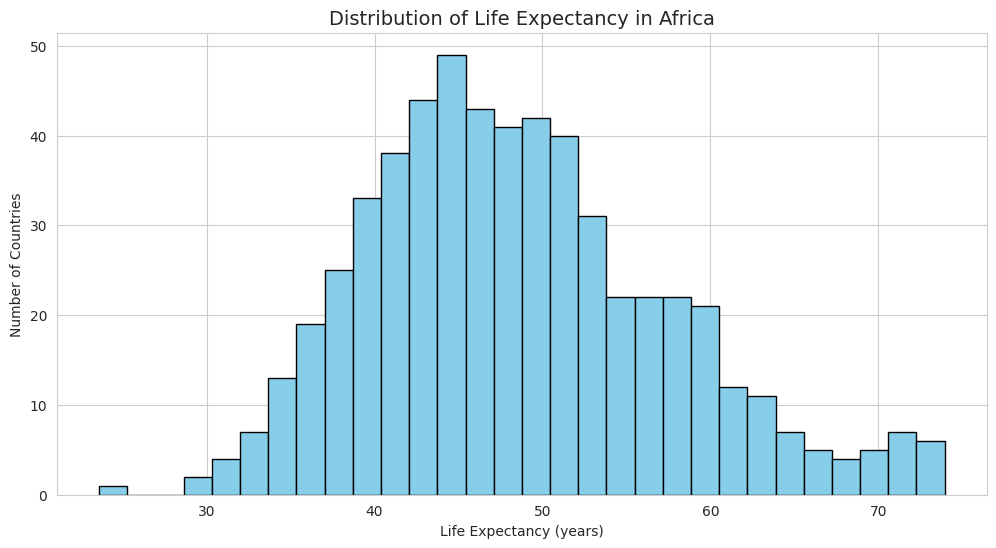

✅ 1. Histogram saved


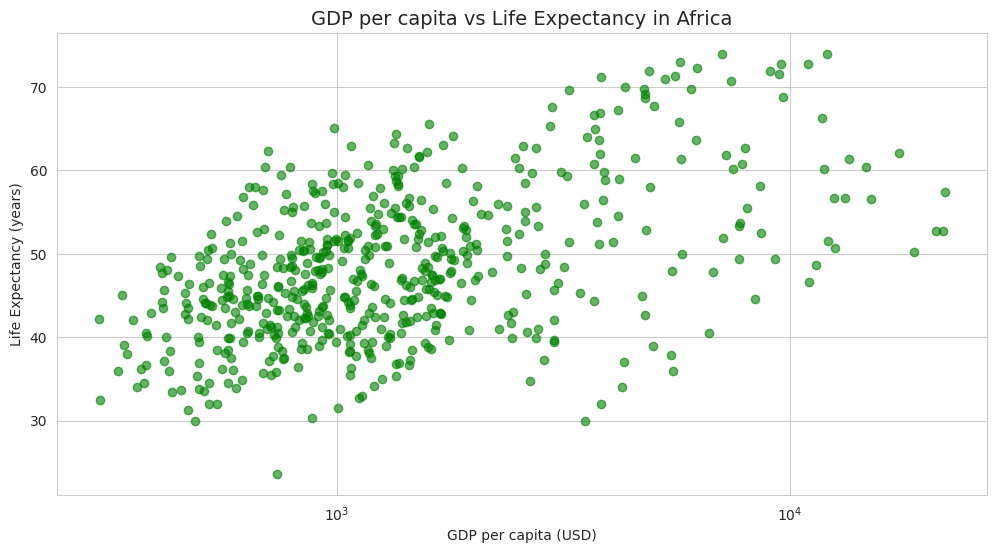

✅ 2. Scatter plot saved


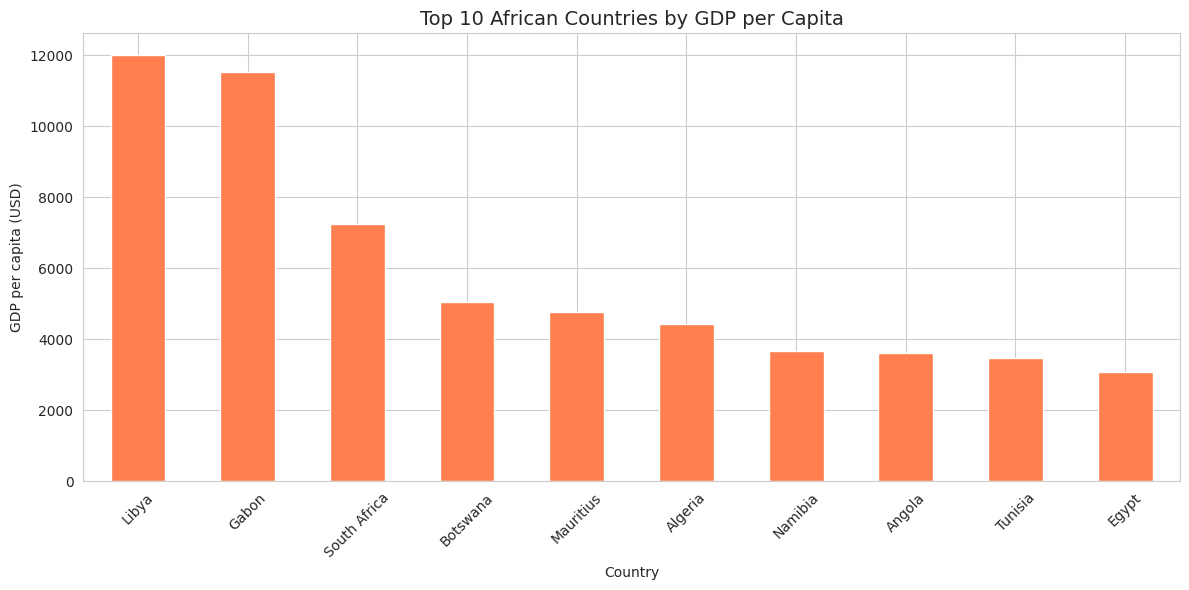

✅ 3. Bar chart saved


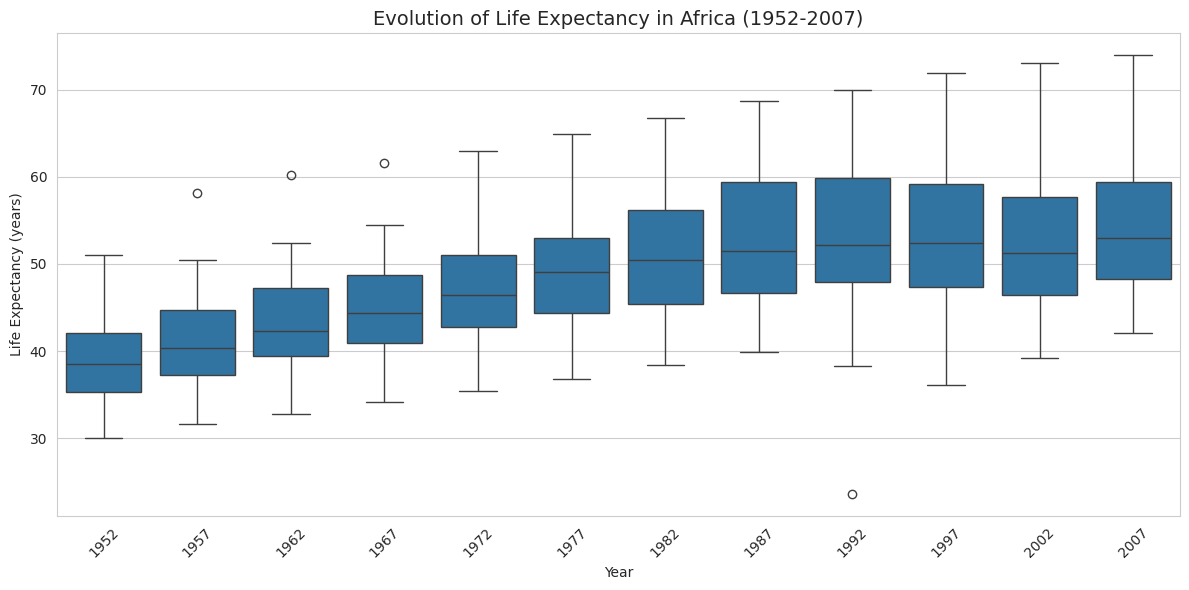

✅ 4. Box plot saved


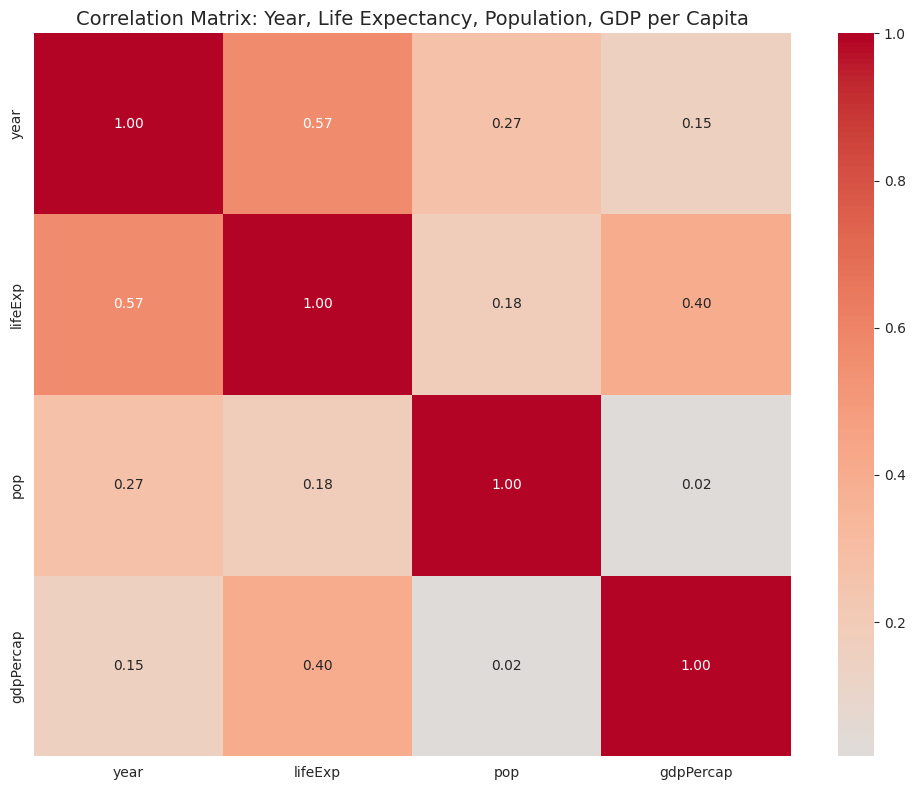

✅ 5. Correlation heatmap saved

🎉 EDA COMPLETED SUCCESSFULLY!

Saved files:
- histogram_life_exp.png
- scatter_gdp_lifeexp.png
- bar_top10_gdp.png
- boxplot_lifeexp_year.png
- heatmap_correlation.png


In [ ]:
# ============================================
# AFRICAN DATA EXPLORATION - EDA
# AISIP Cohort 1 - Week 4 Hands-On Task
# Author: Abdel-aziz Abakar Tahir
# ============================================

# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries imported successfully")

# 2. Load real African dataset (World Bank / Gapminder)
url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"
df = pd.read_csv(url)

# List of African countries
african_countries = [
    'Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi',
    'Cabo Verde', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros',
    'Congo', 'Congo Dem. Rep.', "Cote d'Ivoire", 'Djibouti', 'Egypt',
    'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia', 'Gabon',
    'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Kenya', 'Lesotho',
    'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Mali', 'Mauritania',
    'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger', 'Nigeria',
    'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Seychelles',
    'Sierra Leone', 'Somalia', 'South Africa', 'South Sudan', 'Sudan',
    'Tanzania', 'Togo', 'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe'
]

df_africa = df[df['country'].isin(african_countries)]
print(f"✅ Dataset loaded: {df_africa.shape[0]} rows, {df_africa.shape[1]} columns")

# 3. Data exploration
print("\n" + "="*50)
print("📊 DATA EXPLORATION")
print("="*50)

print("\n🔹 Shape (rows, columns):", df_africa.shape)

print("\n🔹 Info():")
df_africa.info()

print("\n🔹 Describe():")
print(df_africa.describe())

print("\n🔹 First 5 rows:")
print(df_africa.head())

# 4. Data cleaning
print("\n" + "="*50)
print("🧹 DATA CLEANING")
print("="*50)

print("\n🔹 Missing values before cleaning:")
print(df_africa.isnull().sum())

df_africa = df_africa.dropna()
print("\n✅ After dropping missing values:", df_africa.shape)

df_africa = df_africa.drop_duplicates()
print("✅ After dropping duplicates:", df_africa.shape)

print("\n🔹 Data types:")
print(df_africa.dtypes)

# 5. Create 5 visualizations
print("\n" + "="*50)
print("📈 CREATING VISUALIZATIONS")
print("="*50)

sns.set_style("whitegrid")

# 5.1 HISTOGRAM: Distribution of Life Expectancy
plt.figure(figsize=(12, 6))
plt.hist(df_africa['lifeExp'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Life Expectancy in Africa', fontsize=14)
plt.xlabel('Life Expectancy (years)')
plt.ylabel('Number of Countries')
plt.savefig('histogram_life_exp.png')
plt.show()
print("✅ 1. Histogram saved")

# 5.2 SCATTER PLOT: GDP per capita vs Life Expectancy
plt.figure(figsize=(12, 6))
plt.scatter(df_africa['gdpPercap'], df_africa['lifeExp'], alpha=0.6, color='green')
plt.title('GDP per capita vs Life Expectancy in Africa', fontsize=14)
plt.xlabel('GDP per capita (USD)')
plt.ylabel('Life Expectancy (years)')
plt.xscale('log')
plt.savefig('scatter_gdp_lifeexp.png')
plt.show()
print("✅ 2. Scatter plot saved")

# 5.3 BAR CHART: Top 10 African countries by GDP per capita
top10 = df_africa.groupby('country')['gdpPercap'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
top10.plot(kind='bar', color='coral')
plt.title('Top 10 African Countries by GDP per Capita', fontsize=14)
plt.xlabel('Country')
plt.ylabel('GDP per capita (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('bar_top10_gdp.png')
plt.show()
print("✅ 3. Bar chart saved")

# 5.4 BOX PLOT: Life Expectancy evolution over time
plt.figure(figsize=(12, 6))
sns.boxplot(x='year', y='lifeExp', data=df_africa)
plt.title('Evolution of Life Expectancy in Africa (1952-2007)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Life Expectancy (years)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('boxplot_lifeexp_year.png')
plt.show()
print("✅ 4. Box plot saved")

# 5.5 CORRELATION HEATMAP
numeric_cols = ['year', 'lifeExp', 'pop', 'gdpPercap']
corr = df_africa[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix: Year, Life Expectancy, Population, GDP per Capita', fontsize=14)
plt.tight_layout()
plt.savefig('heatmap_correlation.png')
plt.show()
print("✅ 5. Correlation heatmap saved")

print("\n" + "="*50)
print("🎉 EDA COMPLETED SUCCESSFULLY!")
print("="*50)
print("\nSaved files:")
print("- histogram_life_exp.png")
print("- scatter_gdp_lifeexp.png")
print("- bar_top10_gdp.png")
print("- boxplot_lifeexp_year.png")
print("- heatmap_correlation.png")
